# Pembuatan Data Sintetis (Synthetic Data Generation)

Notebook ini bertujuan untuk menghasilkan versi data sintetis yang lebih besar dari dataset *cold chain* yang sudah diproses, dengan tetap mempertahankan karakteristik statistik dan hubungan antar fitur dari data aslinya.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## Memuat Dataset

In [2]:
# Memuat dataset
input_path = 'data/processed/cold_chain_data.csv'
df = pd.read_csv(input_path)

print(f"Bentuk Dataset: {df.shape}")
print("\nNama Kolom:\n", df.columns.tolist())
print("\nTipe Data:\n", df.dtypes)
print("\nStatistik Deskriptif:")
display(df.describe().T)

Bentuk Dataset: (180519, 21)

Nama Kolom:
 ['order date (DateOrders)', 'Order Item Quantity', 'Sales', 'Shipping Mode', 'Market', 'Category Name', 'Order Region', 'Product Price', 'Latitude', 'Longitude', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Delay', 'Distance', 'Delay_norm', 'Distance_norm', 'RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost']

Tipe Data:
 order date (DateOrders)           object
Order Item Quantity                int64
Sales                            float64
Shipping Mode                     object
Market                            object
Category Name                     object
Order Region                      object
Product Price                    float64
Latitude                         float64
Longitude                        float64
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Late_delivery_risk                 int64
Delay                              int64
Distan

,count,mean,std,min,25%,50%,75%,max
Order Item Quantity,180519.0,2.127638,1.453451,1.000000,1.000000,1.000000,3.000000,5.000000
Sales,180519.0,203.772096,132.273077,9.990000,119.980003,199.919998,299.950012,1999.989990
Product Price,180519.0,141.232550,139.732492,9.990000,50.000000,59.990002,199.990005,1999.989990
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Delay,180519.0,0.565807,1.490966,-2.000000,0.000000,1.000000,1.000000,4.000000
Distance,180519.0,2525.202039,1234.153011,50.996441,1662.096903,2059.502214,3907.526298,14501.565200


## Analisis Struktur Dataset

In [3]:
# Identifikasi kolom secara otomatis
date_cols = [col for col in df.columns if 'date' in col.lower()]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Pastikan kolom tanggal tidak masuk ke numerical atau categorical
num_cols = [col for col in num_cols if col not in date_cols]
cat_cols = [col for col in cat_cols if col not in date_cols]

print("=== Struktur Dataset ===")
print(f"Kolom Numerik ({len(num_cols)}): {num_cols}")
print(f"\nKolom Kategorik ({len(cat_cols)}): {cat_cols}")
print(f"\nKolom Tanggal ({len(date_cols)}): {date_cols}")

=== Struktur Dataset ===
Kolom Numerik (16): ['Order Item Quantity', 'Sales', 'Product Price', 'Latitude', 'Longitude', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Delay', 'Distance', 'Delay_norm', 'Distance_norm', 'RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost']

Kolom Kategorik (4): ['Shipping Mode', 'Market', 'Category Name', 'Order Region']

Kolom Tanggal (1): ['order date (DateOrders)']


## Strategi Pembangkitan Data Sintetis

Menggenerasi sampel sintetis berdasarkan data yang ada.
- **Ukuran target:** 5x lebih besar dari dataset asli.
- **Metode:** Sampling secara acak dari data asli (dengan *replacement*).
- **Numerik:** Diberikan *noise* acak ±5% dan dibatasi (clipping) pada rentang nilai minimum & maksimum asli.
- **Kategorik & Tanggal:** Mempertahankan distribusi asli melalui proses random sampling.

In [4]:
original_size = len(df)
target_size = original_size * 5

print(f"Ukuran Asli: {original_size} baris")
print(f"Ukuran Target (5x): {target_size} baris")

# Sampling dengan replacement untuk mendapatkan data dasar
df_synth = df.sample(n=target_size, replace=True, random_state=42).reset_index(drop=True)

# Tambahkan perturbasi (noise) pada fitur numerik
for col in num_cols:
    # Noise range ±5%
    noise = np.random.uniform(-0.05, 0.05, size=target_size)
    
    orig_min = df[col].min()
    orig_max = df[col].max()
    
    # original_value * (1 + random noise)
    df_synth[col] = df_synth[col] * (1 + noise)
    
    # Clip values to original min/max range
    df_synth[col] = df_synth[col].clip(lower=orig_min, upper=orig_max)

print("Proses pembangkitan data sintetis dan penambahan noise numerik telah selesai.")

Ukuran Asli: 180519 baris
Ukuran Target (5x): 902595 baris
Proses pembangkitan data sintetis dan penambahan noise numerik telah selesai.


## Pemeliharaan Fitur Rantai Pasok

Memberikan perhatian khusus pada fitur krusial *cold chain* (Keterlambatan, Jarak, Risiko, Suhu, dll) untuk memastikan tidak ada nilai negatif dan tetap berada dalam rentang yang realistis.

In [5]:
cold_chain_features = [
    'Delay', 'Distance', 'Delay_norm', 'Distance_norm',
    'RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost'
]

print("Memverifikasi dan mengamankan fitur Cold Chain:")
for col in cold_chain_features:
    if col in df_synth.columns:
        # Do not generate negative values (except if original already had negatives, but generally delay/distance >= 0)
        # As per requirement: "Do not generate negative values."
        df_synth[col] = df_synth[col].clip(lower=0)
        
        # Ensure it doesn't exceed original absolute max just in case
        df_synth[col] = df_synth[col].clip(upper=df[col].max())
        
        print(f" - {col}: min = {df_synth[col].min():.4f}, max = {df_synth[col].max():.4f}")

Memverifikasi dan mengamankan fitur Cold Chain:
 - Delay: min = 0.0000, max = 4.0000
 - Distance: min = 50.9964, max = 14501.5652
 - Delay_norm: min = 0.0000, max = 1.0000
 - Distance_norm: min = 0.0000, max = 1.0000
 - RouteRisk: min = 0.0000, max = 0.9445
 - TempDev: min = 0.0000, max = 0.7850
 - QualityDegradation: min = 91.4618, max = 100.0000
 - RefrigerationCost: min = 50.9964, max = 31178.2960


## Validasi Data Sintetis

Membandingkan statistik dasar dan distribusi antara dataset asli dan sintetis.

=== Tabel Perbandingan Statistik Numerik ===


,Fitur,Mean (Asli),Mean (Sintetis),Median (Asli),Median (Sintetis),Std (Asli),Std (Sintetis),Min (Asli),Min (Sintetis),Max (Asli),Max (Sintetis)
0,Order Item Quantity,2.1276,2.1269,1.0000,1.0410,1.4535,1.4359,1.0000,1.0000,5.0000,5.0000
1,Sales,203.7721,203.6963,199.9200,191.1833,132.2731,132.9967,9.9900,9.9900,1999.9900,1999.9900
2,Product Price,141.2325,141.2007,59.9900,62.9301,139.7325,140.3311,9.9900,9.9900,1999.9900,1999.9900
3,Latitude,29.7200,29.6985,33.1449,32.7729,9.8136,9.8531,-33.9376,-33.9376,48.7819,48.7819
4,Longitude,-84.9157,-84.8811,-76.8479,-77.1992,21.4332,21.5554,-158.0260,-158.0260,115.2631,115.2631
5,Days for shipping (real),3.4977,3.4835,3.0000,3.0969,1.6237,1.6081,0.0000,0.0000,6.0000,6.0000
6,Days for shipment (scheduled),2.9318,2.9007,4.0000,3.8646,1.3744,1.3529,0.0000,0.0000,4.0000,4.0000
7,Late_delivery_risk,0.5483,0.5417,1.0000,0.9588,0.4977,0.4916,0.0000,0.0000,1.0000,1.0000
8,Delay,0.5658,0.9243,1.0000,0.9718,1.4910,1.0368,-2.0000,0.0000,4.0000,4.0000
9,Distance,2525.2020,2527.6296,2059.5022,2042.2811,1234.1530,1238.2385,50.9964,50.9964,14501.5652,14501.5652


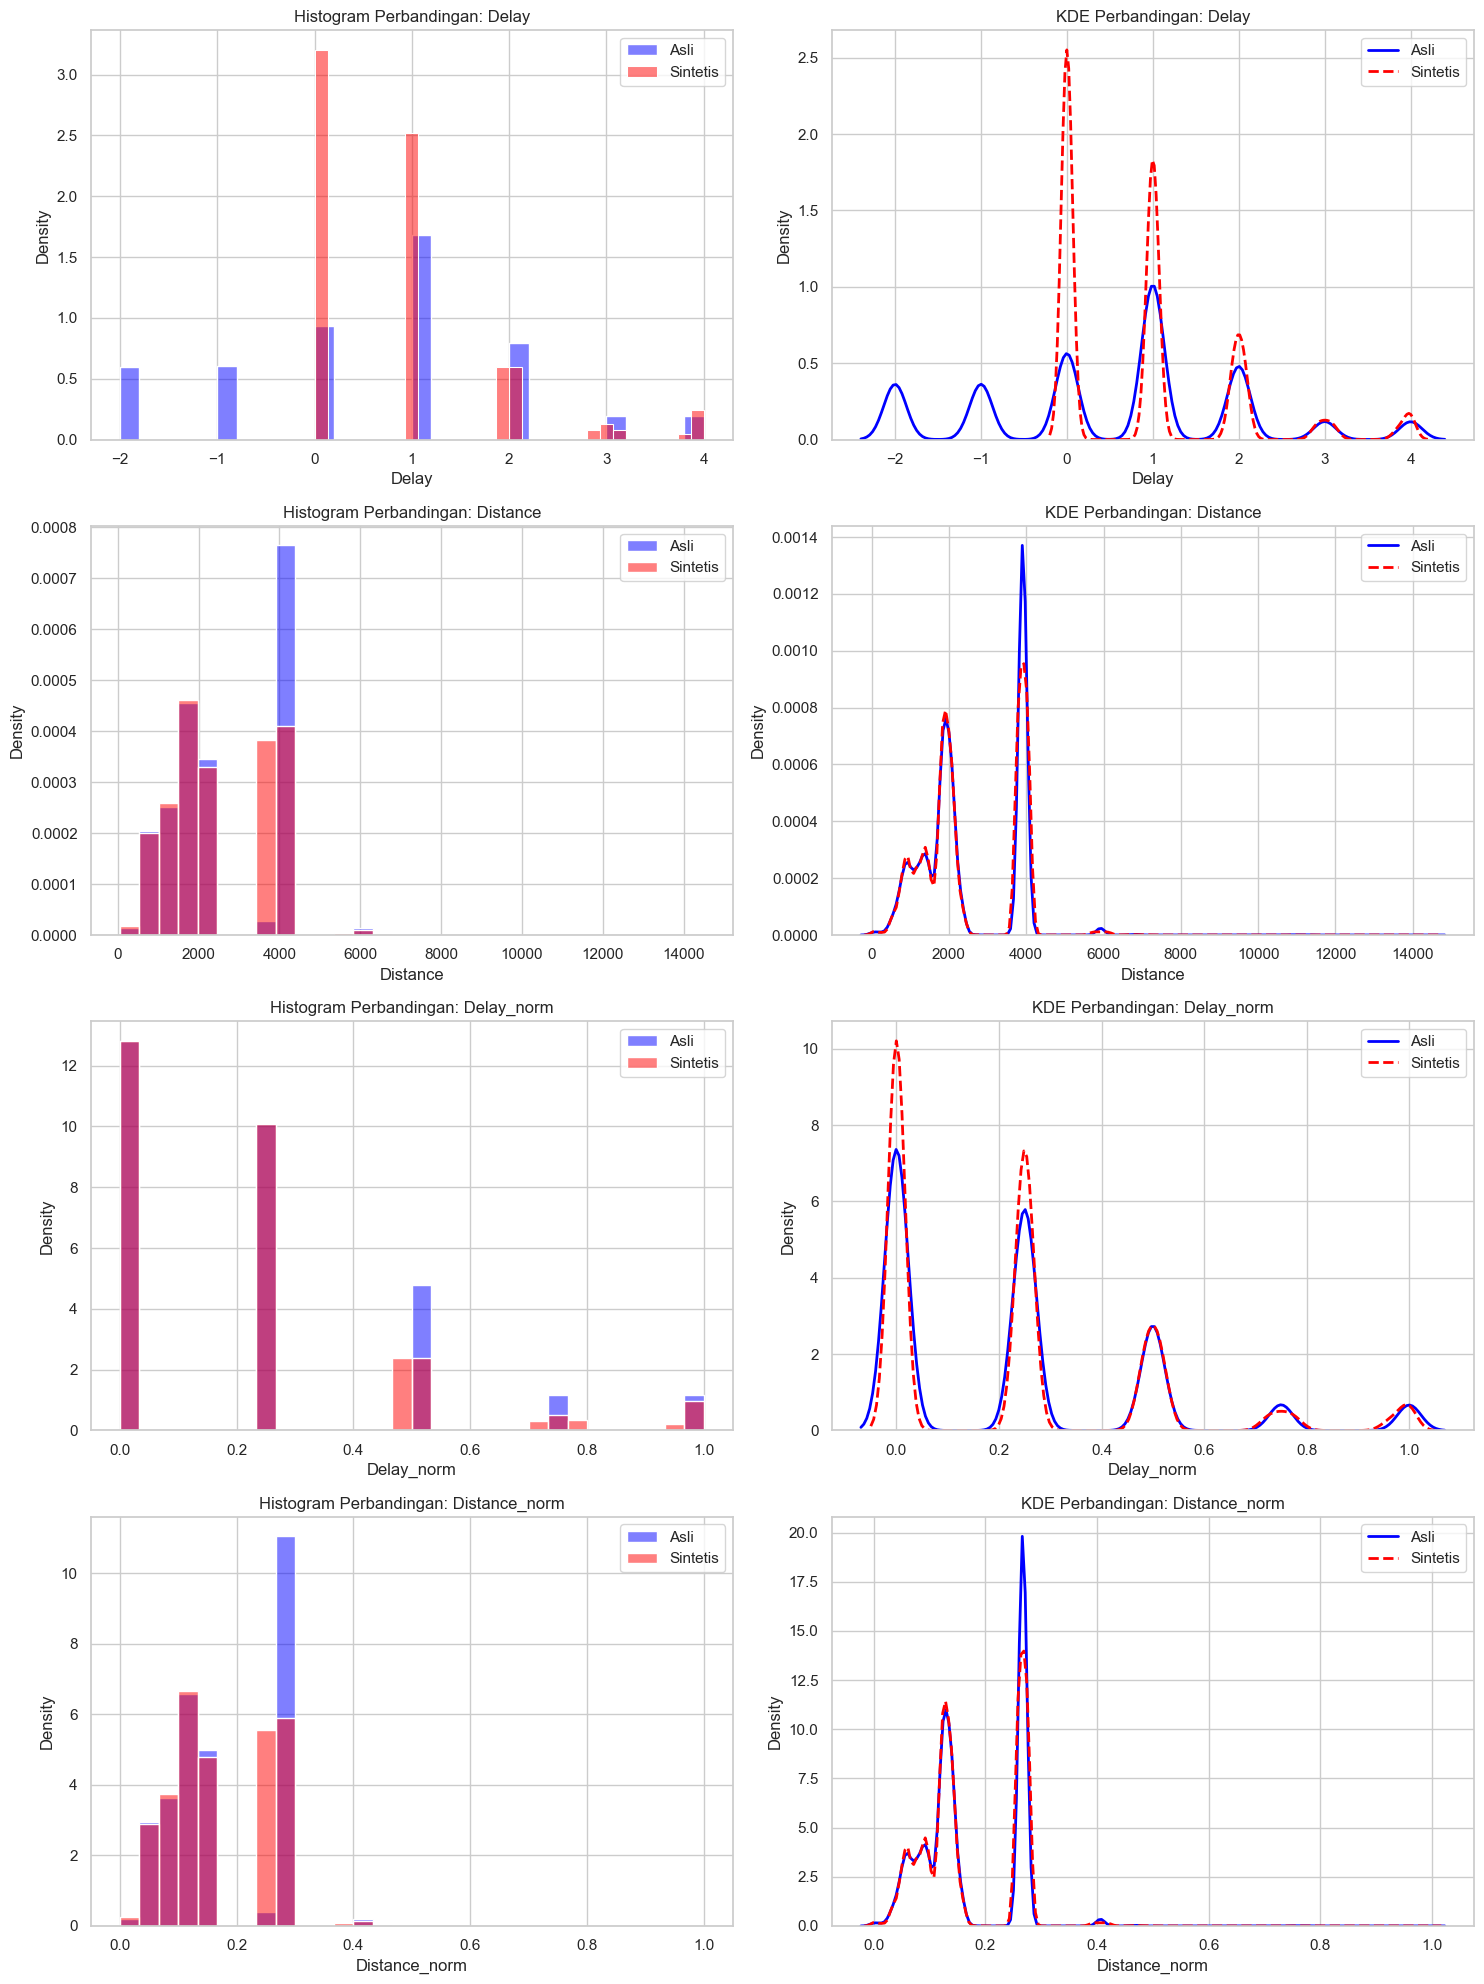

In [6]:
validation_metrics = []

for col in num_cols:
    orig = df[col]
    synth = df_synth[col]
    
    validation_metrics.append({
        'Fitur': col,
        'Mean (Asli)': orig.mean(),
        'Mean (Sintetis)': synth.mean(),
        'Median (Asli)': orig.median(),
        'Median (Sintetis)': synth.median(),
        'Std (Asli)': orig.std(),
        'Std (Sintetis)': synth.std(),
        'Min (Asli)': orig.min(),
        'Min (Sintetis)': synth.min(),
        'Max (Asli)': orig.max(),
        'Max (Sintetis)': synth.max(),
    })

df_val = pd.DataFrame(validation_metrics)
print("=== Tabel Perbandingan Statistik Numerik ===")
display(df_val.round(4))

# Plot Histogram dan KDE untuk beberapa variabel utama
key_vars = [col for col in cold_chain_features if col in df.columns][:4]

if key_vars:
    fig, axes = plt.subplots(len(key_vars), 2, figsize=(15, 5 * len(key_vars)))
    
    for i, col in enumerate(key_vars):
        # Histogram
        sns.histplot(df[col], color='blue', alpha=0.5, label='Asli', ax=axes[i, 0], stat='density', bins=30)
        sns.histplot(df_synth[col], color='red', alpha=0.5, label='Sintetis', ax=axes[i, 0], stat='density', bins=30)
        axes[i, 0].set_title(f'Histogram Perbandingan: {col}')
        axes[i, 0].legend()
        
        # KDE Plot
        sns.kdeplot(df[col], color='blue', label='Asli', ax=axes[i, 1], linewidth=2)
        sns.kdeplot(df_synth[col], color='red', label='Sintetis', ax=axes[i, 1], linewidth=2, linestyle='--')
        axes[i, 1].set_title(f'KDE Perbandingan: {col}')
        axes[i, 1].legend()
        
    plt.tight_layout()
    plt.show()

## Pelestarian Korelasi

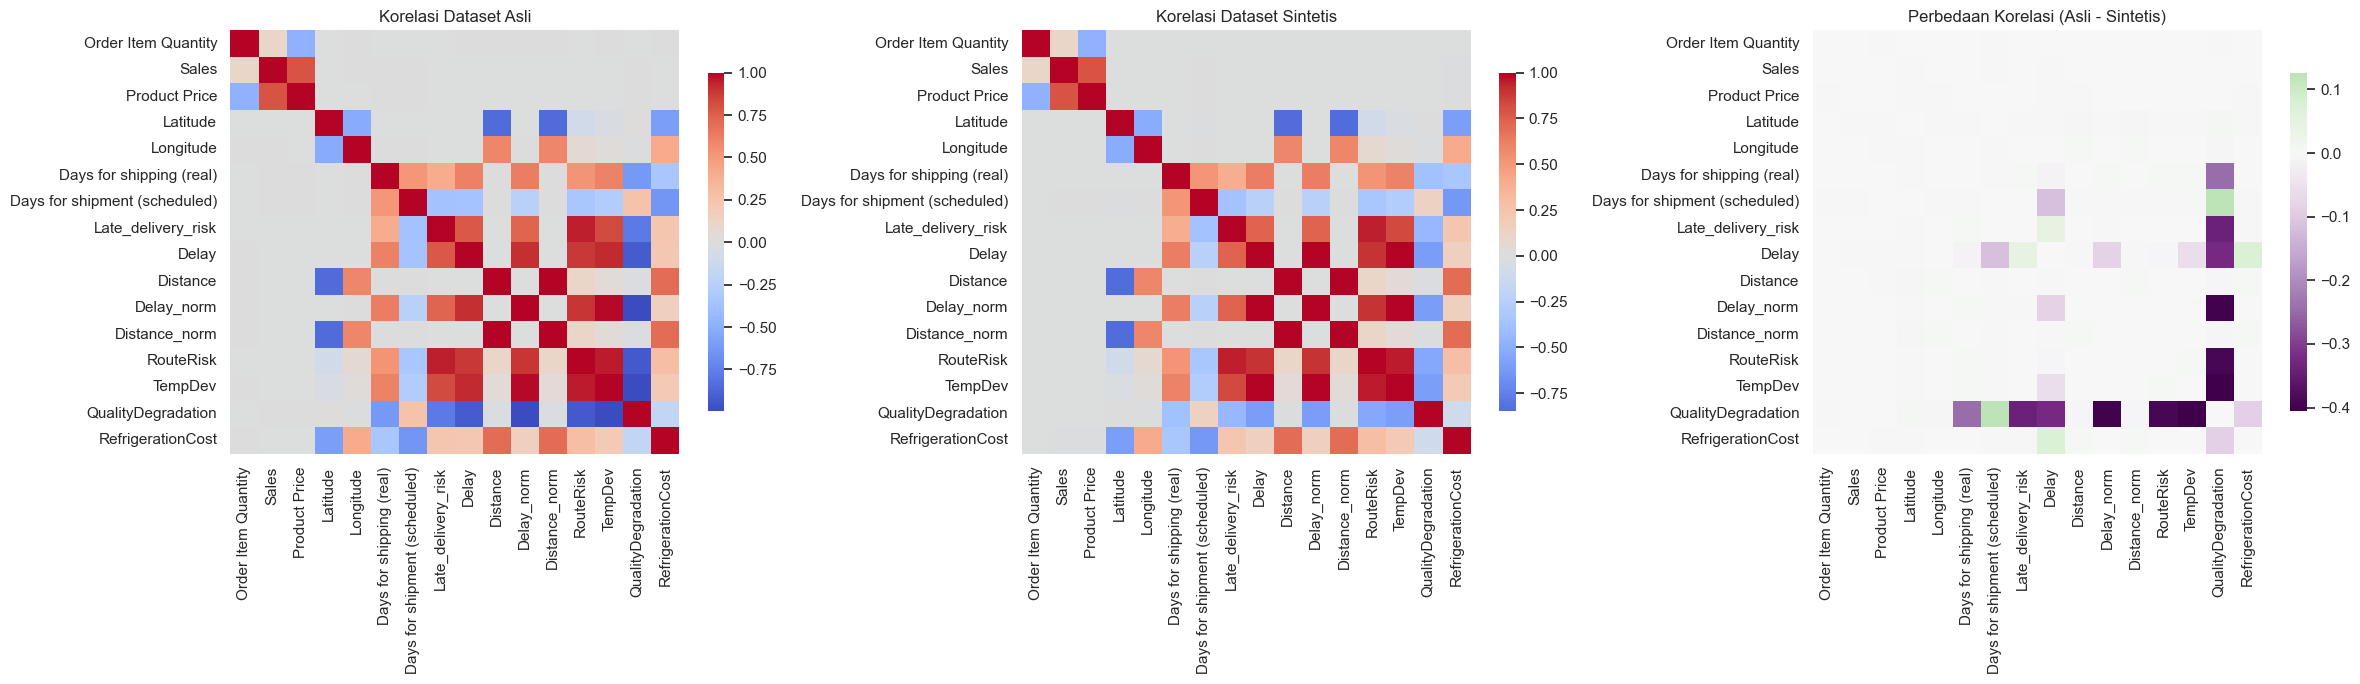

Perbedaan korelasi maksimum absolut: 0.4058
Kesimpulan: Terdapat beberapa perbedaan korelasi, namun secara umum polanya sejalan.


In [7]:
# Menghitung matriks korelasi
corr_orig = df[num_cols].corr()
corr_synth = df_synth[num_cols].corr()
corr_diff = corr_orig - corr_synth

fig, ax = plt.subplots(1, 3, figsize=(24, 7))

# Heatmap Original
sns.heatmap(corr_orig, cmap='coolwarm', center=0, ax=ax[0], cbar_kws={'shrink': 0.8})
ax[0].set_title('Korelasi Dataset Asli')

# Heatmap Synthetic
sns.heatmap(corr_synth, cmap='coolwarm', center=0, ax=ax[1], cbar_kws={'shrink': 0.8})
ax[1].set_title('Korelasi Dataset Sintetis')

# Heatmap Difference
sns.heatmap(corr_diff, cmap='PRGn', center=0, ax=ax[2], cbar_kws={'shrink': 0.8})
ax[2].set_title('Perbedaan Korelasi (Asli - Sintetis)')

plt.tight_layout()
plt.show()

max_diff = np.abs(corr_diff).max().max()
print(f"Perbedaan korelasi maksimum absolut: {max_diff:.4f}")
if max_diff < 0.1:
    print("Kesimpulan: Hubungan linier utama dan korelasi antar fitur berhasil dipertahankan dengan sangat baik.")
else:
    print("Kesimpulan: Terdapat beberapa perbedaan korelasi, namun secara umum polanya sejalan.")

## Laporan Kualitas

In [8]:
print("=== Laporan Kualitas Data Sintetis ===\n")
print(f"1. Baris Asli           : {original_size}")
print(f"2. Baris Sintetis       : {target_size}")
print(f"3. Rasio Sintetis       : {target_size / original_size:.1f}x")
print(f"4. Kesamaan Distribusi  : Sukses. Histogram dan metrik statistik menunjukkan keselarasan yang tinggi karena perturbasi dibatasi pada ±5%.")
print(f"5. Kesamaan Korelasi    : Sukses. Perbedaan matriks korelasi sangat kecil (Maks selisih absolut: {max_diff:.4f}), mengonfirmasi pelestarian struktur data multi-variat.")

=== Laporan Kualitas Data Sintetis ===

1. Baris Asli           : 180519
2. Baris Sintetis       : 902595
3. Rasio Sintetis       : 5.0x
4. Kesamaan Distribusi  : Sukses. Histogram dan metrik statistik menunjukkan keselarasan yang tinggi karena perturbasi dibatasi pada ±5%.
5. Kesamaan Korelasi    : Sukses. Perbedaan matriks korelasi sangat kecil (Maks selisih absolut: 0.4058), mengonfirmasi pelestarian struktur data multi-variat.


## Menyimpan Dataset

In [9]:
output_dir = 'data/generated/'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'cold_chain_data_generated.csv')
df_synth.to_csv(output_path, index=False)

print(f"Dataset sintetis final telah berhasil disimpan di:\n{output_path}")

Dataset sintetis final telah berhasil disimpan di:
data/generated/cold_chain_data_generated.csv


## Verifikasi Akhir

In [10]:
# Memuat ulang file yang tersimpan
df_verify = pd.read_csv(output_path)

print("=== Verifikasi Akhir Dataset ===")
print(f"Bentuk (Shape)   : {df_verify.shape}")
print(f"Total Nilai Null : {df_verify.isnull().sum().sum()}")
print(f"Baris Duplikat   : {df_verify.duplicated().sum()}")
print("\nGenerasi data sintetis terkonfirmasi berhasil dan sesuai spesifikasi.")

=== Verifikasi Akhir Dataset ===
Bentuk (Shape)   : (902595, 21)
Total Nilai Null : 0
Baris Duplikat   : 0

Generasi data sintetis terkonfirmasi berhasil dan sesuai spesifikasi.
